# 🎓 Schrödinger's Cat — INSTRUCTOR DEMO NOTEBOOK
### Elements of Data Science | Live Class Demonstration

---

In [1]:
# ── Setup ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datascience import *
%matplotlib inline

# Set a global random seed so the demo is reproducible
# INSTRUCTOR: change or remove this to show randomness live
np.random.seed(42)
print('Libraries loaded. Ready to go!')

Libraries loaded. Ready to go!


## Here is the set up
![Schrodinger's Cat](SCat.png)

---
## Demo 1 — The Beam Splitter as a Probability Machine

**Key points:**
- A 50/50 beam splitter is a perfect coin flip in disguise
- `np.random.random()` returns a number uniformly between 0 and 1
- If that number is less than `p`, the photon was transmitted

**Key question:** *"If I run this cell 10 times, will I always get the same result?"*

In [5]:
# DEMO 1a — Single measurement

p = 0.5   # beam splitter reflectivity

r = np.random.random()
print(f'Random draw: {r:.4f}')

if r < p:
    print('Photon TRANSMITTED  →  Cat gets a treat! 🐟')
else:
    print('Photon REFLECTED    →  Sleep gas released! 😴')

Random draw: 0.9645
Photon REFLECTED    →  Sleep gas released! 😴


In [4]:
# DEMO 1b — Change the reflectivity
# -------------------------------------------------------
# Ask: "What if the mirror is 70% reflective?
# Is the cat more likely to be asleep?"
# -------------------------------------------------------
for reflectivity in [0.3, 0.5, 0.7]:
    results = np.random.random(10000) < reflectivity   # True = reflected
    pct_asleep = results.mean() * 100
    print(f'Reflectivity {int(reflectivity*100):2d}%  →  '
          f'Cat asleep {pct_asleep:.1f}% of trials  '
          f'(expected {int(reflectivity*100)}%)')

Reflectivity 30%  →  Cat asleep 30.5% of trials  (expected 30%)
Reflectivity 50%  →  Cat asleep 49.4% of trials  (expected 50%)
Reflectivity 70%  →  Cat asleep 70.5% of trials  (expected 70%)


**Discussion prompt:** The reflectivity *is* the probability. The physics doesn't add anything extra — the beam splitter **is** a probability generator. This is what Schrödinger found so unsettling.

---
## Demo 2 — Law of Large Numbers

**Talking points:**
- One trial tells us nothing reliable about `p`
- As trials accumulate, the running frequency converges to `p`
- This is *how* quantum mechanics makes predictions — not about single events, but about many

**Key question:** *"Why do physicists need to repeat experiments?"*

In [6]:
# DEMO 2a — Build a results Table step by step
p     = 0.5
n     = 500

draws    = np.random.random(n)
outcomes = np.where(draws < p, 'treat', 'sleep')

results = Table().with_columns(
    'trial',   np.arange(1, n + 1),
    'draw',    np.round(draws, 4),
    'outcome', outcomes
)

print(f'First 8 trials:')
results.show(8)

# Summary counts
counts = results.group('outcome')
freqs  = counts.with_column(
    'frequency', np.round(counts.column('count') / n, 3)
)
print('\nSummary:')
freqs.show()

First 8 trials:


trial,draw,outcome
1,0.219,treat
2,0.5879,sleep
3,0.7002,sleep
4,0.8256,sleep
5,0.407,treat
6,0.6869,sleep
7,0.3032,treat
8,0.4355,treat



Summary:


outcome,count,frequency
sleep,252,0.504
treat,248,0.496


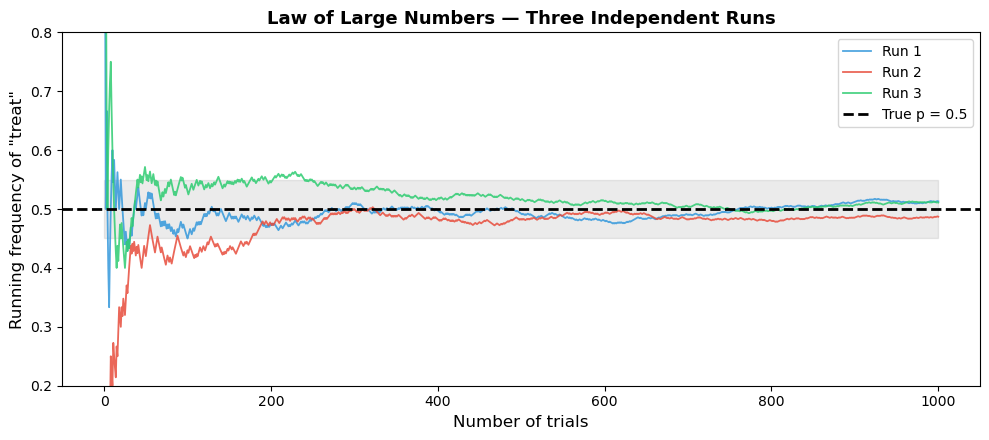


Question: roughly how many trials before all three runs stay within ±5% of 0.5?


In [8]:
# DEMO 2b — Running frequency plot
# -------------------------------------------------------
# Show THREE different runs simultaneously to highlight
# that each converges but from different paths
# -------------------------------------------------------
n = 1000
fig, ax = plt.subplots(figsize=(10, 4.5))

colors = ['#3498db', '#e74c3c', '#2ecc71']
for i, color in enumerate(colors):
    draws = np.random.random(n)
    is_treat = draws < 0.5
    running  = np.cumsum(is_treat) / np.arange(1, n + 1)
    ax.plot(np.arange(1, n + 1), running, color=color,
            lw=1.3, alpha=0.85, label=f'Run {i+1}')

ax.axhline(0.5, color='black', lw=2, linestyle='--', label='True p = 0.5')
ax.set_xlabel('Number of trials',  fontsize=12)
ax.set_ylabel('Running frequency of "treat"', fontsize=12)
ax.set_title('Law of Large Numbers — Three Independent Runs', fontsize=13, fontweight='bold')
ax.set_ylim(0.2, 0.8)
ax.legend(fontsize=10)
ax.fill_between([0, n], [0.45, 0.45], [0.55, 0.55],
                alpha=0.08, color='black', label='±5% band')
plt.tight_layout()
plt.show()

print('\nQuestion: roughly how many trials before all three runs stay within ±5% of 0.5?')

---
## Demo 3 — The Wave Function is a Probability Distribution

**Talking points:**
- Schrödinger's equation doesn't just give two outcomes — it gives a *continuous* distribution over position
- `|ψₙ(x)|²` is the probability density: integrate over any region to get the probability of finding the particle there
- Show the formula, then show it's *just a numpy array*

**Key question:** *"What do the flat regions (nodes) mean physically?"*

In [9]:
# DEMO 3a — Build |ψ|² from scratch, narrating each line
L = 1.0
x = np.linspace(0, L, 1000)   # 1000 positions from 0 to L

def psi(x, n, L):
    """Wave function ψₙ(x) for a particle in a box."""
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)

def psi_squared(x, n, L):
    """Probability density |ψₙ(x)|² — just square the wave function."""
    return psi(x, n, L) ** 2

# Verify it's normalised (must integrate to 1)
dx = x[1] - x[0]   # spacing between points
for n in [1, 2, 3]:
    total = np.sum(psi_squared(x, n, L)) * dx
    print(f'n={n}  →  integral of |ψ|² = {total:.4f}  (should be 1.0)')

n=1  →  integral of |ψ|² = 1.0000  (should be 1.0)
n=2  →  integral of |ψ|² = 1.0000  (should be 1.0)
n=3  →  integral of |ψ|² = 1.0000  (should be 1.0)


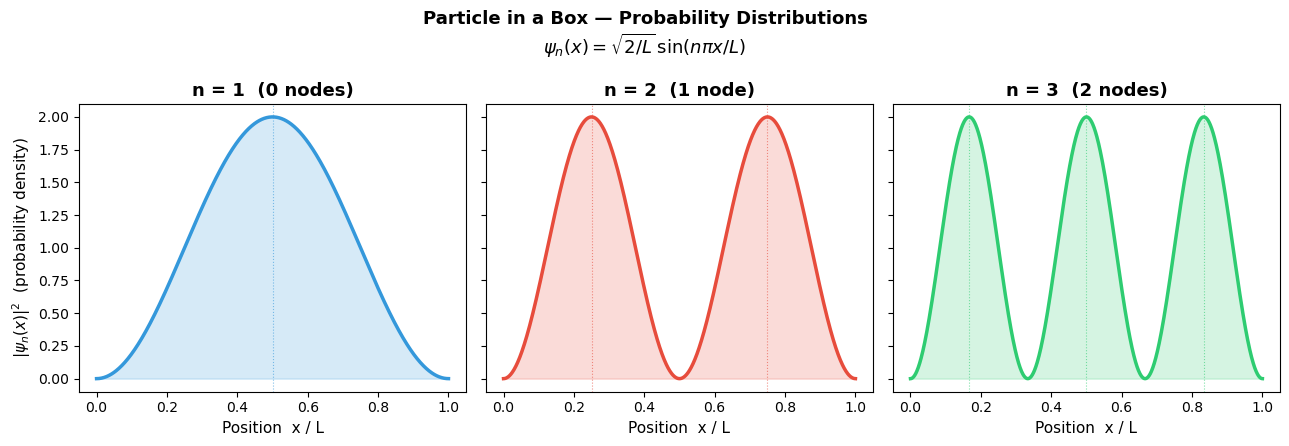


Pattern: n energy level  →  (n-1) nodes  →  n peaks (antinodes)


In [10]:
# DEMO 3b — Plot all three energy levels side by side
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
colors  = ['#3498db', '#e74c3c', '#2ecc71']
n_nodes = [0, 1, 2]   # nodes for n=1,2,3

for i, n in enumerate([1, 2, 3]):
    prob = psi_squared(x, n, L)
    axes[i].plot(x, prob, color=colors[i], lw=2.5)
    axes[i].fill_between(x, prob, alpha=0.2, color=colors[i])
    axes[i].set_title(f'n = {n}  ({n_nodes[i]} node{"" if n_nodes[i]==1 else "s"})',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Position  x / L', fontsize=11)
    # Mark the antinodes (peaks)
    peak_x = [(2*k - 1) / (2 * n) for k in range(1, n + 1)]
    for px in peak_x:
        axes[i].axvline(px, color=colors[i], lw=0.8, linestyle=':', alpha=0.6)

axes[0].set_ylabel(r'$|\psi_n(x)|^2$  (probability density)', fontsize=11)
fig.suptitle('Particle in a Box — Probability Distributions\n'
             r'$\psi_n(x) = \sqrt{2/L}\,\sin(n\pi x/L)$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPattern: n energy level  →  (n-1) nodes  →  n peaks (antinodes)')

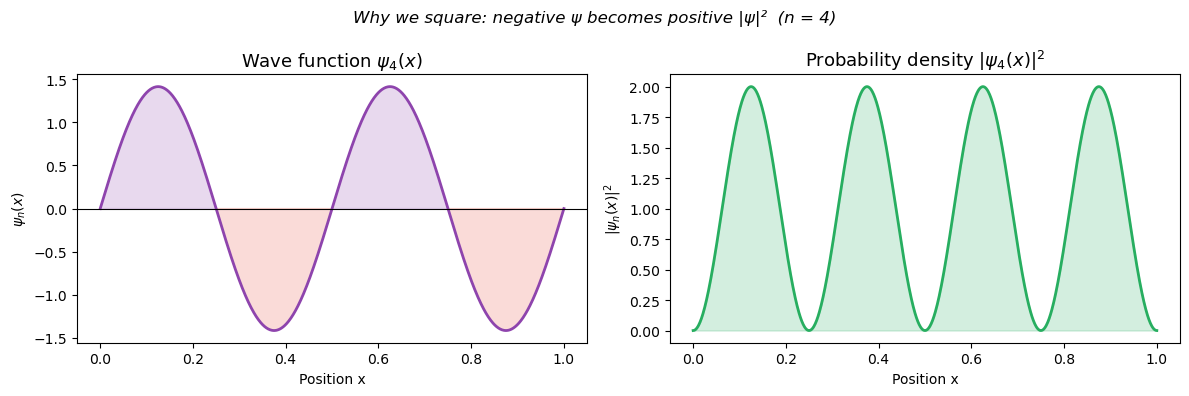

Nodes: 3   |   Antinodes: 4


In [11]:
# DEMO 3c — Interactive energy level explorer
# -------------------------------------------------------
# Change n_level live during class to show pattern
# -------------------------------------------------------
n_level = 4   # <-- change this during class!

prob = psi_squared(x, n_level, L)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: wave function ψ itself
axes[0].plot(x, psi(x, n_level, L), color='#8e44ad', lw=2)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].fill_between(x, psi(x, n_level, L), 0,
                     where=psi(x, n_level, L) > 0, alpha=0.2, color='#8e44ad')
axes[0].fill_between(x, psi(x, n_level, L), 0,
                     where=psi(x, n_level, L) < 0, alpha=0.2, color='#e74c3c')
axes[0].set_title(rf'Wave function $\psi_{{{n_level}}}(x)$', fontsize=13)
axes[0].set_xlabel('Position x')
axes[0].set_ylabel(r'$\psi_n(x)$')

# Right: |ψ|² — squaring removes negative regions
axes[1].plot(x, prob, color='#27ae60', lw=2)
axes[1].fill_between(x, prob, alpha=0.2, color='#27ae60')
axes[1].set_title(rf'Probability density $|\psi_{{{n_level}}}(x)|^2$', fontsize=13)
axes[1].set_xlabel('Position x')
axes[1].set_ylabel(r'$|\psi_n(x)|^2$')

fig.suptitle(f'Why we square: negative ψ becomes positive |ψ|²  (n = {n_level})',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()
print(f'Nodes: {n_level - 1}   |   Antinodes: {n_level}')

---
## Demo 4 — Sampling from a Quantum Distribution

**Talking points:**
- `|ψ|²` is *exactly* like the probability array we use in `np.random.choice`
- Normalising it to sum to 1 is the same as saying "total probability = 1"
- Each sample simulates one position measurement of the particle
- More measurements → histogram matches the theoretical distribution

**Key question:** *"Is the particle 'really' at a specific location before we measure it?"*

In [12]:
# DEMO 4a — Show sampling step by step
n_level  = 2
n_points = 1000
x        = np.linspace(0, L, n_points)
prob     = psi_squared(x, n_level, L)

# Step 1: compute weights
weights = prob / prob.sum()
print(f'weights sum to: {weights.sum():.6f}  (must equal 1.0 for np.random.choice)')
print(f'Smallest weight: {weights.min():.6f}   Largest weight: {weights.max():.6f}')
print(f'Nodes (zero-probability positions): {np.sum(weights < 1e-6)} grid points')

weights sum to: 1.000000  (must equal 1.0 for np.random.choice)
Smallest weight: 0.000000   Largest weight: 0.002002
Nodes (zero-probability positions): 16 grid points


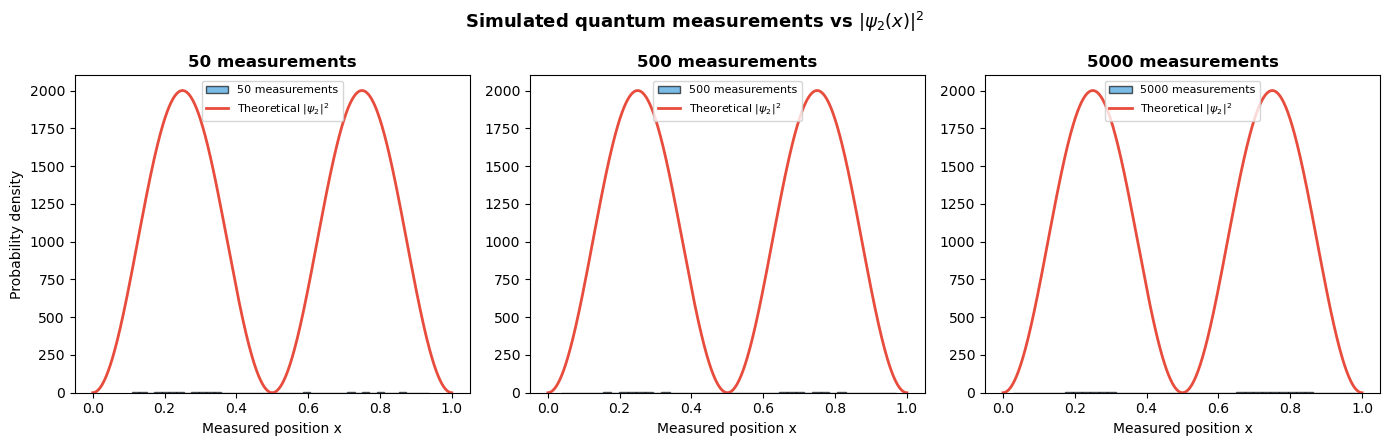


The histogram approaches the theory curve as n grows — Law of Large Numbers again!


In [13]:
# DEMO 4b — Progressive sampling: 50, 500, 5000 shots
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)
shot_counts = [50, 500, 5000]

x_theory = np.linspace(0, L, n_points)
theory   = psi_squared(x_theory, n_level, L) * n_points  # rescale to density

for i, n_shots in enumerate(shot_counts):
    measurements = np.random.choice(x, size=n_shots, p=weights)
    axes[i].hist(measurements, bins=40, density=True,
                 color='#3498db', alpha=0.65,
                 label=f'{n_shots} measurements')
    axes[i].plot(x_theory, theory, color='#e74c3c', lw=2,
                 label=r'Theoretical $|\psi_2|^2$')
    axes[i].set_title(f'{n_shots} measurements', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Measured position x')
    if i == 0:
        axes[i].set_ylabel('Probability density')
    axes[i].legend(fontsize=8)

fig.suptitle(r'Simulated quantum measurements vs $|\psi_2(x)|^2$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nThe histogram approaches the theory curve as n grows — Law of Large Numbers again!')

In [14]:
# DEMO 4c — Store measurements in a Table and compute statistics
n_shots      = 5000
measurements = np.random.choice(x, size=n_shots, p=weights)

meas_table = Table().with_columns(
    'shot',     np.arange(1, n_shots + 1),
    'position', np.round(measurements, 4)
)
meas_table.show(6)

print(f"\nMean measured position:   {meas_table.column('position').mean():.4f}  (expected 0.5)")
print(f"Std dev of measurements:  {meas_table.column('position').std():.4f}")
print()
print('Where is the particle NEVER found?')
# Bin measurements to find empty bins (nodes)
counts, edges = np.histogram(measurements, bins=20)
node_bins     = np.where(counts == 0)[0]
for b in node_bins:
    print(f'  Zero counts between x = {edges[b]:.2f} and {edges[b+1]:.2f}  ← this is a NODE')

shot,position
1,0.3934
2,0.2412
3,0.2452
4,0.3303
5,0.1752
6,0.2132



Mean measured position:   0.4973  (expected 0.5)
Std dev of measurements:  0.2659

Where is the particle NEVER found?


---
## Demo 5 — Superposition

**Talking points:**
- Quantum mechanics allows states to *add*, not just be one or the other
- Coefficients must satisfy `|c₁|² + |c₂|² = 1` (total probability = 1)
- The resulting `|ψ|²` is *not* the average of the two — it has interference effects
- This is exactly the equation shown in the beam splitter diagram

**Key question:** *"Is the superposition |ψ|² just the average of n=1 and n=2? Let's check."*

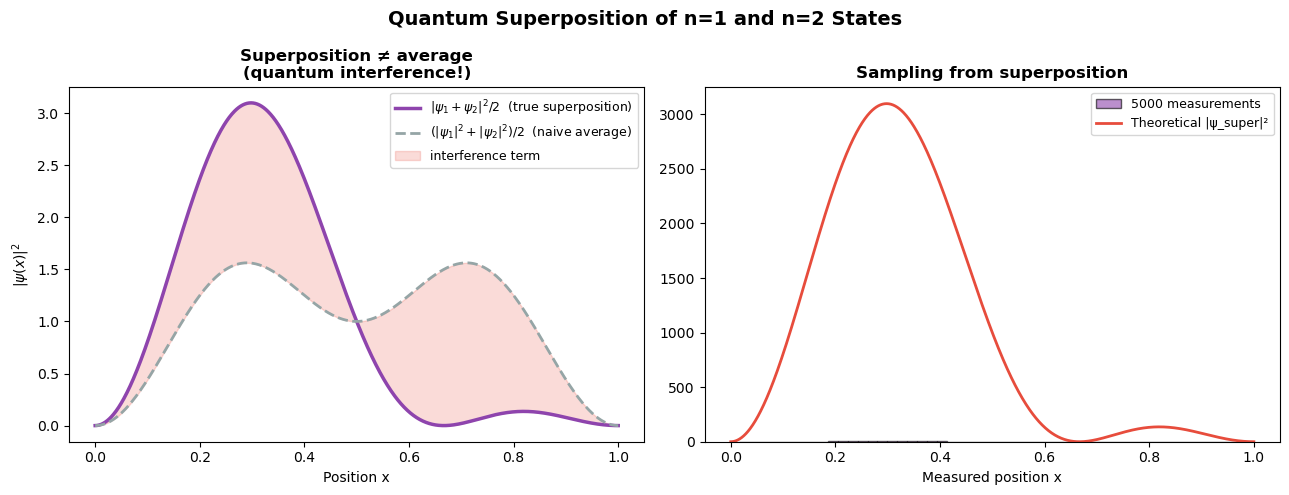

Integral of superposition |ψ|²: 1.0000  (must = 1.0)


In [15]:
# DEMO 5a — Equal superposition of n=1 and n=2
x = np.linspace(0, L, 1000)

p1 = psi_squared(x, 1, L)
p2 = psi_squared(x, 2, L)

# Superposition: ψ = (1/√2)ψ₁ + (1/√2)ψ₂
c1, c2     = 1/np.sqrt(2), 1/np.sqrt(2)
psi_super  = c1 * psi(x, 1, L) + c2 * psi(x, 2, L)
prob_super = psi_super ** 2

# Naive average (WRONG — shows interference matters)
prob_avg   = 0.5 * p1 + 0.5 * p2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: compare superposition vs naive average
axes[0].plot(x, prob_super, color='#8e44ad', lw=2.5,
             label=r'$|\psi_1 + \psi_2|^2/2$  (true superposition)')
axes[0].plot(x, prob_avg,   color='#95a5a6', lw=2, linestyle='--',
             label=r'$(|\psi_1|^2 + |\psi_2|^2)/2$  (naive average)')
axes[0].fill_between(x, prob_super, prob_avg, alpha=0.2, color='#e74c3c',
                     label='interference term')
axes[0].set_title('Superposition ≠ average\n(quantum interference!)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Position x')
axes[0].set_ylabel(r'$|\psi(x)|^2$')
axes[0].legend(fontsize=9)

# Right: sample from superposition
weights_super = prob_super / prob_super.sum()
meas_super    = np.random.choice(x, size=5000, p=weights_super)
axes[1].hist(meas_super, bins=50, density=True,
             color='#8e44ad', alpha=0.6, label='5000 measurements')
axes[1].plot(x, prob_super * 1000, color='#e74c3c', lw=2,
             label='Theoretical |ψ_super|²')
axes[1].set_title('Sampling from superposition', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Measured position x')
axes[1].legend(fontsize=9)

fig.suptitle('Quantum Superposition of n=1 and n=2 States',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Integral of superposition |ψ|²: {np.sum(prob_super) * (x[1]-x[0]):.4f}  (must = 1.0)')

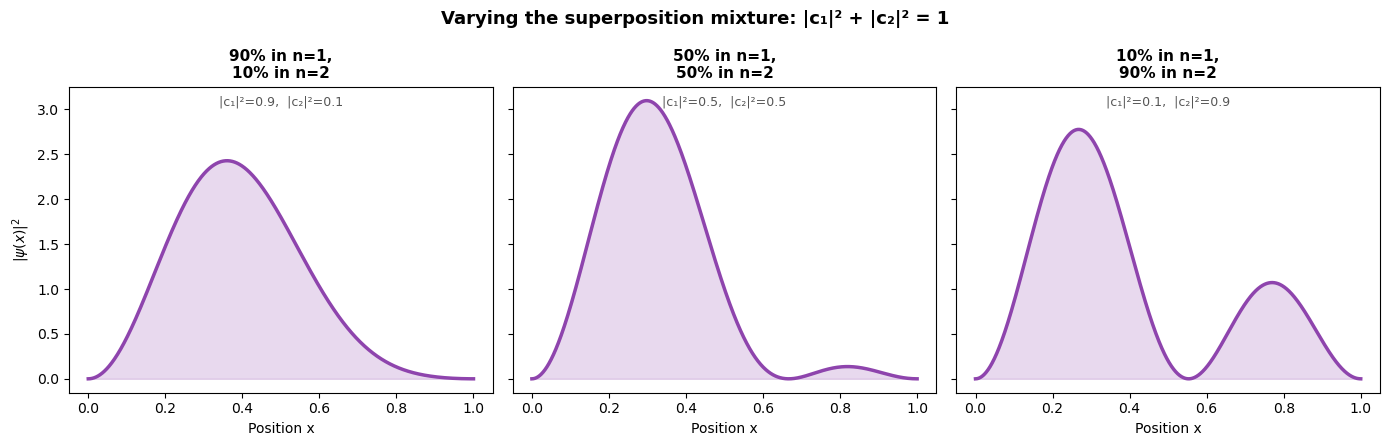

This is the direct analogue of changing beam splitter reflectivity from Demo 1!


In [16]:
# DEMO 5b — Vary the mixture coefficient
# -------------------------------------------------------
# Show how changing c1, c2 shifts probability between states
# Connect back to the beam splitter: c1²=p, c2²=(1-p)
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

# (c1², c2²) = (0.9, 0.1), (0.5, 0.5), (0.1, 0.9)
mixtures = [(0.9, 0.1), (0.5, 0.5), (0.1, 0.9)]
titles   = ['90% in n=1,\n10% in n=2',
            '50% in n=1,\n50% in n=2',
            '10% in n=1,\n90% in n=2']

for i, (w1, w2) in enumerate(mixtures):
    c1 = np.sqrt(w1)
    c2 = np.sqrt(w2)
    ps = (c1 * psi(x, 1, L) + c2 * psi(x, 2, L)) ** 2
    axes[i].plot(x, ps, lw=2.5, color='#8e44ad')
    axes[i].fill_between(x, ps, alpha=0.2, color='#8e44ad')
    axes[i].set_title(titles[i], fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Position x')
    axes[i].text(0.5, 0.97, f'|c₁|²={w1},  |c₂|²={w2}',
                 transform=axes[i].transAxes,
                 ha='center', va='top', fontsize=9, color='#555')

axes[0].set_ylabel(r'$|\psi(x)|^2$')
fig.suptitle('Varying the superposition mixture: |c₁|² + |c₂|² = 1',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('This is the direct analogue of changing beam splitter reflectivity from Demo 1!')

---
## Demo 6 — Connecting Everything Back to the Cat

**Use this as a closing summary cell — run it last.**

Demonstrates the full pipeline: beam splitter → many cats → frequency → probability, all in one narrative.

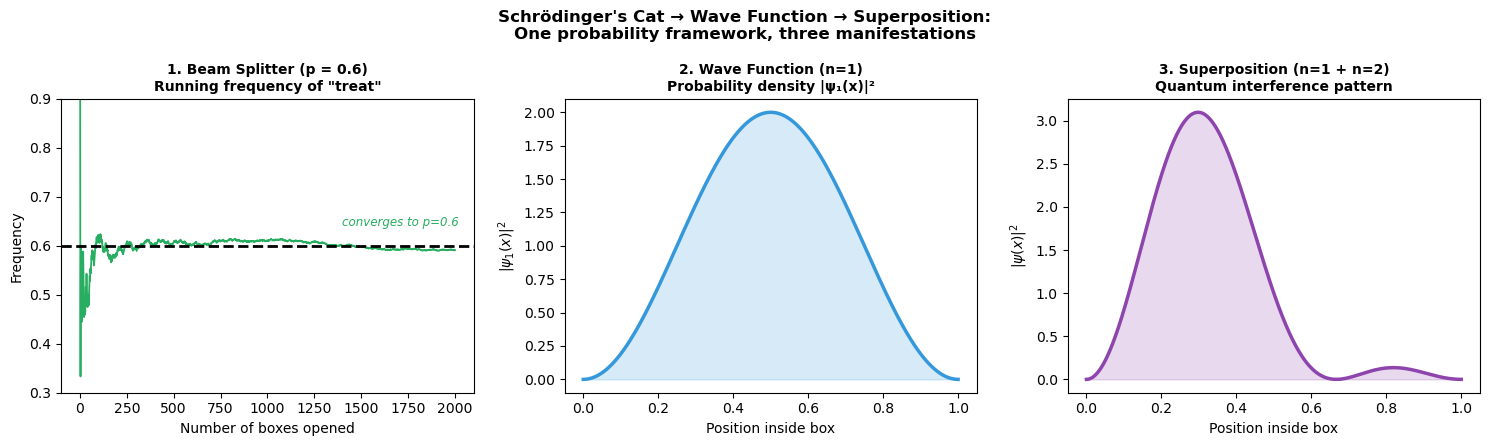

In [17]:
# DEMO 6 — Full summary simulation
np.random.seed(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: Beam splitter — discrete outcomes ─────────────────
p     = 0.6   # 60% chance of treat
n     = 2000
draws = np.random.random(n)
treat = (draws < p).cumsum() / np.arange(1, n+1)

axes[0].plot(np.arange(1, n+1), treat, color='#27ae60', lw=1.3)
axes[0].axhline(p, color='black', lw=2, linestyle='--')
axes[0].set_title('1. Beam Splitter (p = 0.6)\nRunning frequency of "treat"',
                  fontsize=10, fontweight='bold')
axes[0].set_ylim(0.3, 0.9)
axes[0].set_xlabel('Number of boxes opened')
axes[0].set_ylabel('Frequency')
axes[0].text(1400, 0.64, 'converges to p=0.6', fontsize=8.5,
             color='#27ae60', fontstyle='italic')

# ── Panel 2: n=1 wave function — continuous probability ────────
x2   = np.linspace(0, L, 1000)
prob = psi_squared(x2, 1, L)
axes[1].plot(x2, prob, color='#3498db', lw=2.5)
axes[1].fill_between(x2, prob, alpha=0.2, color='#3498db')
axes[1].set_title('2. Wave Function (n=1)\nProbability density |ψ₁(x)|²',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Position inside box')
axes[1].set_ylabel(r'$|\psi_1(x)|^2$')

# ── Panel 3: Superposition — both at once ──────────────────────
ps = (1/np.sqrt(2) * psi(x2, 1, L) + 1/np.sqrt(2) * psi(x2, 2, L)) ** 2
axes[2].plot(x2, ps, color='#8e44ad', lw=2.5)
axes[2].fill_between(x2, ps, alpha=0.2, color='#8e44ad')
axes[2].set_title('3. Superposition (n=1 + n=2)\nQuantum interference pattern',
                  fontsize=10, fontweight='bold')
axes[2].set_xlabel('Position inside box')
axes[2].set_ylabel(r'$|\psi(x)|^2$')

fig.suptitle("Schrödinger's Cat → Wave Function → Superposition:\n"
             'One probability framework, three manifestations',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Instructor Cheat Sheet — Transition to Student Notebook

| Demo cell | Maps to student exercise | Key skill practiced |
|---|---|---|
| Demo 1a | Ex 1.1 | `if/else` with `np.random.random()` |
| Demo 1b | Ex 1.2 | Interpreting randomness |
| Demo 2a | Ex 2.1–2.2 | `np.where`, `Table.group()`, frequencies |
| Demo 2b | Ex 2.3 | `np.cumsum`, running frequency plot |
| Demo 3b | Ex 3.1 | Implementing `psi_squared`, plotting |
| Demo 3c | Ex 3.2 | Conceptual understanding of nodes |
| Demo 4b | Ex 4.1 | `np.random.choice` with weights |
| Demo 4b/4c | Ex 4.2 | Varying `n_shots`, LLN connection |
| Demo 5a | Ex 5.1 | Superposition formula, sampling |
| Demo 5a | Ex 5.2 | Big-picture reflection |

> **Tip:** In Demo 3c, live-change `n_level` from 1 → 6 before students have opened the student notebook. The pattern of nodes is memorable and gives them the answer to Exercise 3.2 question 3 — intentionally, so they focus their effort on the coding in Exercises 4 and 5.